# Imports

In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import matplotlib.pyplot as plt
import awkward           as ak
import numpy             as np
import pandas            as pd

from nHits_trigger.src.read_data          import nHits, read_mpmt_offsets
from WCTE_BRB_Data_Analysis.wcte.brbtools import sort_run_files, get_part_files
from matplotlib.backends.backend_pdf      import PdfPages

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Read DFs And Start Playing

In [2]:
df_sig = pd.read_csv("data_files/df_sigFromKaMing_forClaudeReco.csv")
df_bkg = pd.read_csv("data_files/df_bkgFromKaMing_forClaudeReco.csv")
df_bump = pd.read_csv("data_files/df_bumpFromKaMing_forClaudeReco.csv")

In [3]:
df_sig

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id
0,0,0,0,65913.196181,75.0,69,17,1328
1,1,0,0,65913.202297,137.0,70,1,1331
2,2,0,0,65913.385377,77.0,75,6,1431
3,3,0,0,65913.529539,101.0,54,9,1035
4,4,0,0,65913.912451,353.0,57,6,1089
...,...,...,...,...,...,...,...,...
3187453,3187453,47108,420317,246554.602468,200.0,65,11,1246
3187454,3187454,47108,420318,292618.984835,104.0,24,13,469
3187455,3187455,47108,420318,292619.252065,84.0,55,14,1059
3187456,3187456,47108,420318,292619.611487,159.0,86,13,1647


In [3]:
nhits_perCandidate_sig = df_sig.groupby("candidate_id")["event_id"].count().values
nhits_perCandidate_bkg = df_bkg.groupby("candidate_id")["event_id"].count().values
nhits_perCandidate_bump = df_bump.groupby("candidate_id")["event_id"].count().values

trms_perCandidate_sig = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values
trms_perCandidate_bkg = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values
trms_perCandidate_bump = df_bump.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values

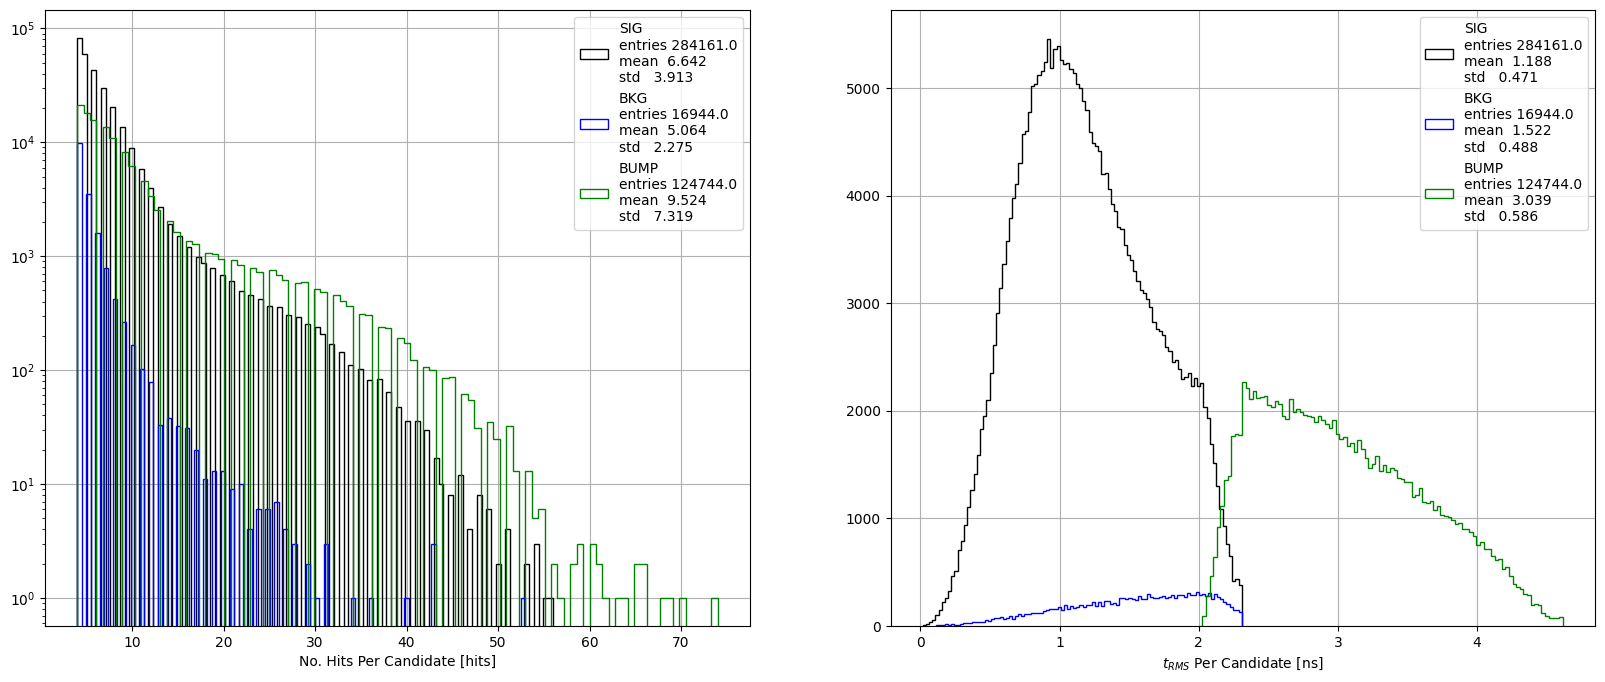

In [4]:
subplot = pltext.canvas(2,2,8,10)

subplot(1)
pltext.hist(nhits_perCandidate_sig, 100, ylog=True, label="SIG", xylabels="No. Hits Per Candidate [hits]");
pltext.hist(nhits_perCandidate_bkg, 100, ylog=True, label="BKG", xylabels="No. Hits Per Candidate [hits]");
pltext.hist(nhits_perCandidate_bump, 100, ylog=True, label="BUMP", xylabels="No. Hits Per Candidate [hits]");

subplot(2)
pltext.hist(trms_perCandidate_sig, 100, ylog=False, label="SIG", xylabels="$t_{RMS}$ Per Candidate [ns]");
pltext.hist(trms_perCandidate_bkg, 100, ylog=False, label="BKG", xylabels="$t_{RMS}$ Per Candidate [ns]");
pltext.hist(trms_perCandidate_bump, 100, ylog=False, label="BUMP", xylabels="$t_{RMS}$ Per Candidate [ns]");

# Afterpulsing Check: Same PMTs hit in df_bump As In df_sig (For The Same Candidate)

In [9]:
candidate = 0
df_bump[df_bump["candidate_id"].values == candidate]["pmt_id"].values, df_sig[df_sig["candidate_id"].values == candidate]["pmt_id"].values

(array([1526, 1239, 1540, 1523, 1535, 1534, 1235, 1543, 1262, 1533, 1965,
        1961, 1960, 1524, 1748, 1755]),
 array([1328, 1331, 1431, 1035, 1089, 1084,  762]))

# Double Signal Check

Median total charge SIG:  849.0 ADC
Median total charge BUMP: 1077.0 ADC
Ratio BUMP/SIG:           1.27x


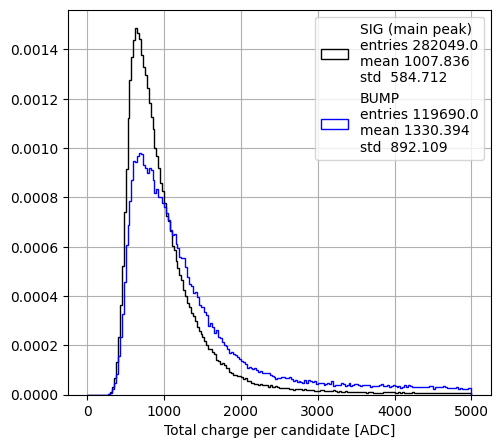

In [11]:
# --- Check 1: Carga total por candidato (proxy de energía) ---
# Si bump = Ni-capture (~9 MeV) y sig = H-capture (~2.2 MeV),
# la carga total del bump debería ser ~4x mayor

charge_sig  = df_sig.groupby("candidate_id")["hit_pmt_charges"].sum()
charge_bump = df_bump.groupby("candidate_id")["hit_pmt_charges"].sum()

subplot = pltext.canvas(1)
subplot(1)
pltext.hist(charge_sig.values,  200, range=(0, 5000), density=True,
            xylabels="Total charge per candidate [ADC]", label="SIG (main peak)")
pltext.hist(charge_bump.values, 200, range=(0, 5000), density=True,
            xylabels="Total charge per candidate [ADC]", label="BUMP")

ratio = charge_bump.median() / charge_sig.median()
print(f"Median total charge SIG:  {charge_sig.median():.1f} ADC")
print(f"Median total charge BUMP: {charge_bump.median():.1f} ADC")
print(f"Ratio BUMP/SIG:           {ratio:.2f}x")

Mean unique slots  SIG:  5.2
Mean unique slots  BUMP: 7.1
Mean PMT/hit ratio SIG:  1.000
Mean PMT/hit ratio BUMP: 1.000


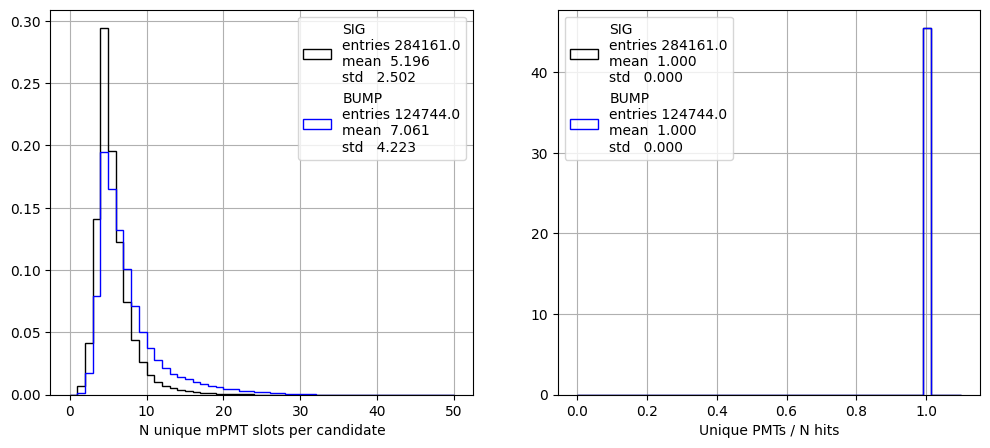

In [12]:
# --- Check 2: Spread espacial de los PMTs activados ---
# Necesitas las posiciones (x,y,z) de cada PMT. Si no las tienes,
# usa como proxy el número de mPMT slots DISTINTOS por candidato.
# Múltiples vértices Cherenkov → más mPMTs distintos activados.

def spatial_spread(df):
    results = []
    for cand_id, group in df.groupby("candidate_id"):
        n_unique_slots = group["hit_mpmt_slot_ids"].nunique()
        n_unique_pmts  = group.groupby(["hit_mpmt_slot_ids", "hit_pmt_position_ids"]).ngroups
        n_hits         = len(group)
        results.append({
            "n_hits"        : n_hits,
            "n_unique_slots": n_unique_slots,
            "n_unique_pmts" : n_unique_pmts,
            "pmt_per_hit"   : n_unique_pmts / n_hits,  # 1.0 = cada hit en PMT distinto
        })
    return pd.DataFrame(results)

spread_sig  = spatial_spread(df_sig)
spread_bump = spatial_spread(df_bump)

subplot = pltext.canvas(2)

subplot(1)
pltext.hist(spread_sig["n_unique_slots"].values,  50, range=(0, 50), density=True,
            xylabels="N unique mPMT slots per candidate", label="SIG")
pltext.hist(spread_bump["n_unique_slots"].values, 50, range=(0, 50), density=True,
            xylabels="N unique mPMT slots per candidate", label="BUMP")

subplot(2)
pltext.hist(spread_sig["pmt_per_hit"].values,  50, range=(0, 1.1), density=True,
            xylabels="Unique PMTs / N hits", label="SIG")
pltext.hist(spread_bump["pmt_per_hit"].values, 50, range=(0, 1.1), density=True,
            xylabels="Unique PMTs / N hits", label="BUMP")

print(f"Mean unique slots  SIG:  {spread_sig['n_unique_slots'].mean():.1f}")
print(f"Mean unique slots  BUMP: {spread_bump['n_unique_slots'].mean():.1f}")
print(f"Mean PMT/hit ratio SIG:  {spread_sig['pmt_per_hit'].mean():.3f}")
print(f"Mean PMT/hit ratio BUMP: {spread_bump['pmt_per_hit'].mean():.3f}")

# Desplegables

(2014,)
(2014,)


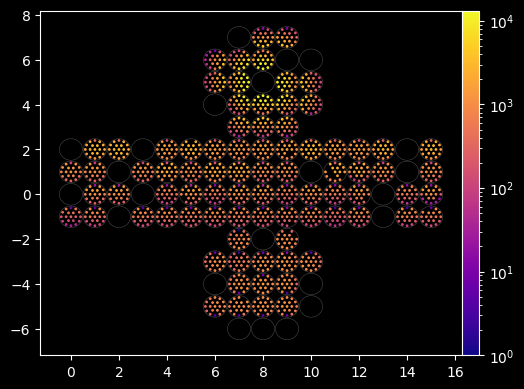

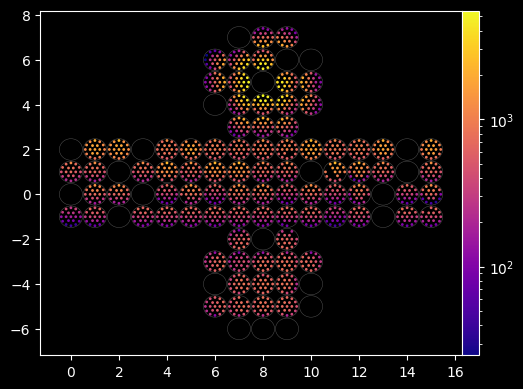

In [18]:
from WCTE_event_display.EventDisplay import EventDisplay
import matplotlib.colors as colors

#1) make an instance of the event display class
eventDisplay = EventDisplay() 

#2) start by loading in the CSV file for how the mPMTs are mapped to 2d event display
#unwraps based on the mPMT slot ID 
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')

#mask out mPMT slots - newer WCSim doesn't have these mPMTs loaded  
#WCTE slot numbering
# eventDisplay.mask_mPMTs([45,77,79,27,32,85,91,99,12,14,16,18])
#WCSim container numbering
# eventDisplay.mask_mPMTs([20,73,38,49,55,65,67,33,71,92,101,95])

#3) load the WCSim mapping tube no to slot number
#for WCSim using the numpy output we need the mapping between the tube_number in WCSim and the slot and mPMT number in the detector
#this can be obtained from the geofile that WCSim produces 
#This changes if the CDS is implemented or not
eventDisplay.load_wcsim_tubeno_mapping("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt")

n_pmts = 2014

# --- Calculamos la escala global según df_sig ---
nhits_sig = df_sig.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
vmin = 1e-1  # mínimo positivo para LogNorm (evitar log(0))
vmax = nhits_sig.max()  # máximo para escalar

# --- df_sig ---
eventDisplay.plotEventDisplay(
    nhits_sig,
    color_norm=colors.LogNorm(),
    style="dark_background"
)

# --- df_bump ---
nhits_bump = df_bump.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_bump,
    color_norm=colors.LogNorm(),
    style="dark_background"
)

plt.style.use('default');
pltext.style()

TEC slots (21): [85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105]
(2014,)
(2014,)


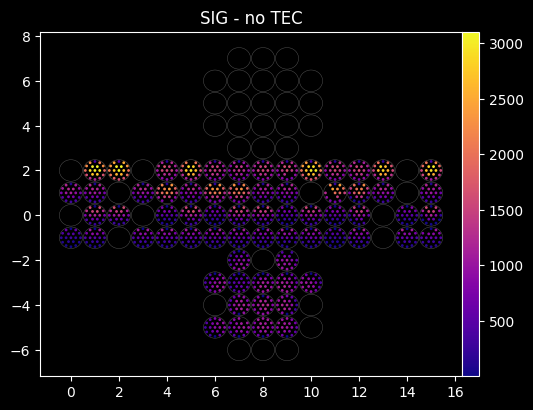

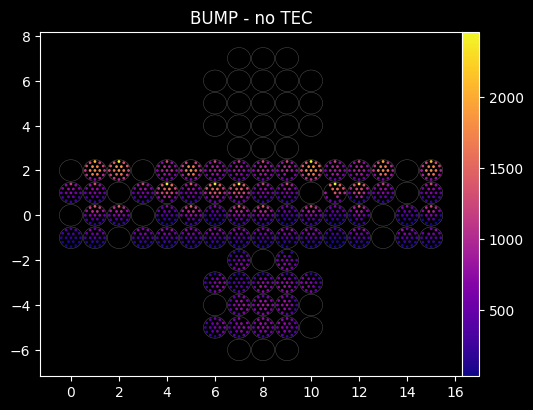

In [21]:
# --- mPMT slots de la tapa de arriba (TEC): y >= 3 en el CSV ---
tec_slots = [i for i, row in enumerate(eventDisplay.mPMT_2D_projection) if row[2] >= 3]
print(f"TEC slots ({len(tec_slots)}): {tec_slots}")

# --- Mask TEC ---
eventDisplay.mask_mPMTs(tec_slots)

# --- Plot SIG sin TEC ---
nhits_sig = df_sig.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_sig,
    color_norm=None,
    style="dark_background"
)
plt.title("SIG - no TEC")

# --- Plot BUMP sin TEC ---
nhits_bump = df_bump.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_bump,
    color_norm=None,
    style="dark_background"
)
plt.title("BUMP - no TEC")

plt.style.use('default')
pltext.style()

# --- Limpiar mask para después ---
eventDisplay.mask_list = None

BUMP candidates: 124744
SIG candidates:  284161
Sampled SIG candidates: 124744
(2014,)
(2014,)


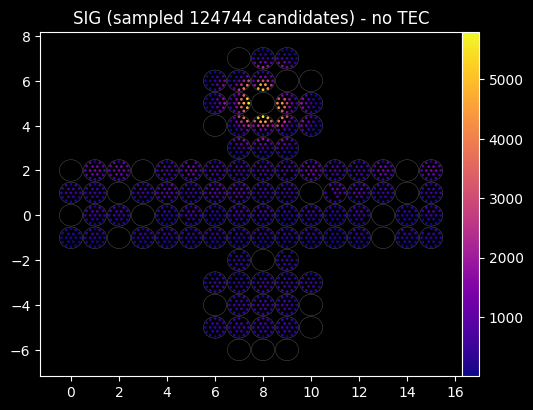

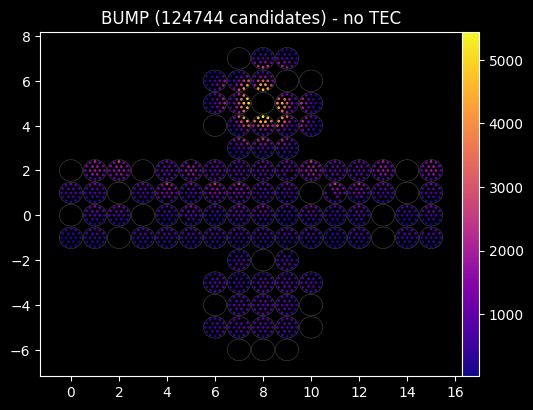

In [30]:
# --- Subsample df_sig to match df_bump candidate count ---
n_bump_candidates = df_bump["candidate_id"].nunique()
n_sig_candidates  = df_sig["candidate_id"].nunique()

print(f"BUMP candidates: {n_bump_candidates}")
print(f"SIG candidates:  {n_sig_candidates}")

# Random sample of sig candidate IDs
np.random.seed(42)
sig_cand_ids = df_sig["candidate_id"].unique()
sampled_ids  = np.random.choice(sig_cand_ids, size=n_bump_candidates, replace=False)
df_sig_sampled = df_sig[df_sig["candidate_id"].isin(sampled_ids)]

print(f"Sampled SIG candidates: {df_sig_sampled['candidate_id'].nunique()}")

# --- Mask TEC ---
# tec_slots = [i for i, row in enumerate(eventDisplay.mPMT_2D_projection) if row[2] >= 3]
# eventDisplay.mask_mPMTs(tec_slots)

# --- Plot SIG (sampled) sin TEC ---
nhits_sig_sampled = df_sig_sampled.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
vmax = max(nhits_sig_sampled.max(), 1)

eventDisplay.plotEventDisplay(
    nhits_sig_sampled,
    color_norm=None,
    style="dark_background"
)
plt.title(f"SIG (sampled {n_bump_candidates} candidates) - no TEC")

# --- Plot BUMP sin TEC ---
nhits_bump = df_bump.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)

eventDisplay.plotEventDisplay(
    nhits_bump,
    color_norm=None,
    style="dark_background"
)
plt.title(f"BUMP ({n_bump_candidates} candidates) - no TEC")

plt.style.use('default')
pltext.style()

# --- Limpiar mask ---
eventDisplay.mask_list = None

(2014,)
(2014,)


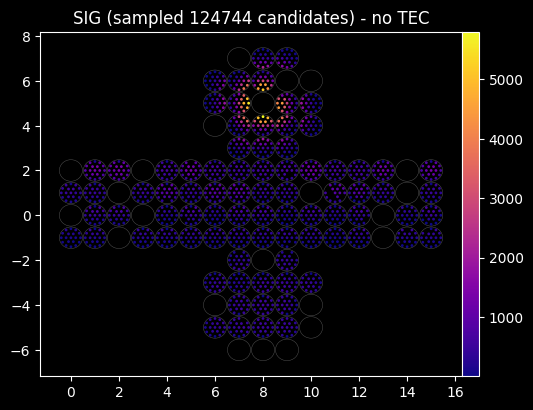

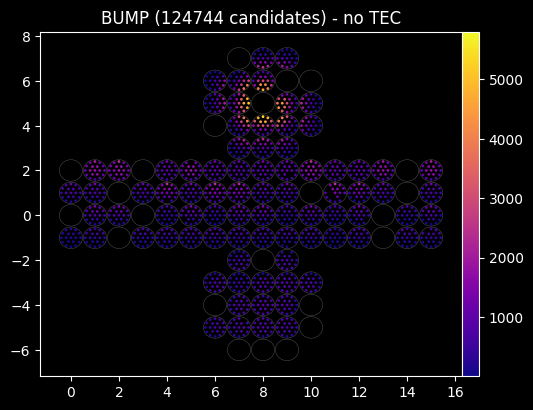

In [32]:
# --- Subsample df_sig to match df_bump candidate count ---
n_bump_candidates = df_bump["candidate_id"].nunique()

np.random.seed(42)
sig_cand_ids = df_sig["candidate_id"].unique()
sampled_ids  = np.random.choice(sig_cand_ids, size=n_bump_candidates, replace=False)
df_sig_sampled = df_sig[df_sig["candidate_id"].isin(sampled_ids)]

# --- Mask TEC ---
# tec_slots = [i for i, row in enumerate(eventDisplay.mPMT_2D_projection) if row[2] >= 3]
# eventDisplay.mask_mPMTs(tec_slots)

# --- Precompute both hit maps and common color scale ---
nhits_sig_sampled = df_sig_sampled.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
nhits_bump = df_bump.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)

vmin = 1e-1
vmax = max(nhits_sig_sampled.max(), nhits_bump.max())

# --- Plot SIG (sampled) ---
eventDisplay.plotEventDisplay(
    nhits_sig_sampled,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)
plt.title(f"SIG (sampled {n_bump_candidates} candidates) - no TEC")

# --- Plot BUMP ---
eventDisplay.plotEventDisplay(
    nhits_bump,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)
plt.title(f"BUMP ({n_bump_candidates} candidates) - no TEC")

plt.style.use('default')
pltext.style()

# --- Limpiar mask ---
eventDisplay.mask_list = None